# Case Study 1: Astrophysical Time Series - Solar Cycle Analysis

## 1. Physical Context
Sunspots are temporary phenomena on the Sun's photosphere that appear as spots darker than the surrounding areas. They are regions of reduced surface temperature caused by concentrations of magnetic field flux that inhibit convection. 

Historical observations of sunspots have been recorded for centuries, revealing a distinct periodicity in solar magnetic activity. This variability significantly impacts space weather, satellite communications, and the Earth's upper atmosphere.

**Your Objective:** You are provided with a historical dataset of the Monthly Mean Total Sunspot Number. Your task is to utilize the Discrete Fourier Transform (DFT) to mathematically isolate and quantify the dominant period of the solar magnetic cycle (often referred to as the Schwabe cycle).

## 2. Mathematical Expectations
The dataset provides the sunspot count $y_n$ at discrete, uniformly spaced time intervals. The sampling interval is one month, meaning $\Delta t = 1/12$ years. 

You will compute the Fast Fourier Transform (FFT) to obtain the frequency-domain components $Y_k$. To find the dominant physical cycle, you must:
1. Compute the normalized power spectrum: $P_k = \frac{2}{N} |Y_k|$
2. Formulate the correct frequency array $f_k$ corresponding to the frequency bins.
3. Identify the frequency $f_{max}$ that yields the maximum spectral power.
4. Convert this frequency into a physical time period $T$ (in years) using the relation:
$$T = \frac{1}{f}$$

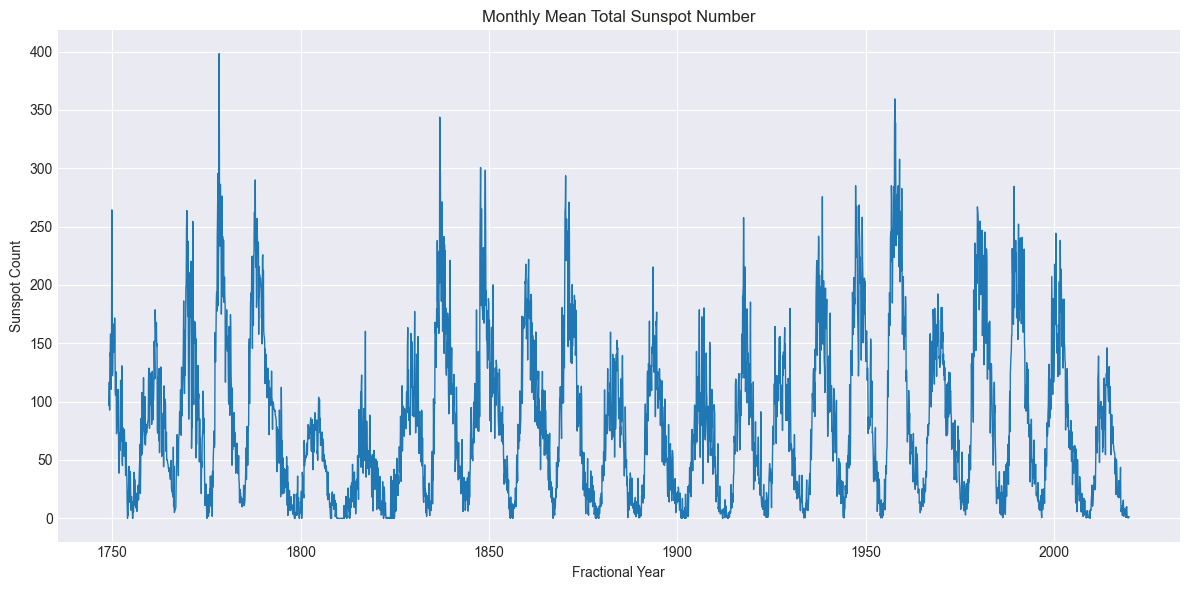

In [31]:
# Import required scientific libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Set plot style for academic formatting
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

# --- TASK 1: Load and plot the raw time-domain data ---

from pathlib import Path

data_path = Path("sunspots.csv")
if not data_path.exists():
    raise FileNotFoundError(f"sunspots.csv not found in {Path.cwd()}")

data = pd.read_csv(data_path)
if "Date" in data.columns and "Monthly Mean Total Sunspot Number" in data.columns:
    data["Date"] = pd.to_datetime(data["Date"])
    t = data["Date"].dt.year + (data["Date"].dt.month - 0.5) / 12
    y = data["Monthly Mean Total Sunspot Number"].values
elif "Fractional_Year" in data.columns and "Sunspot_Count" in data.columns:
    t = data["Fractional_Year"]
    y = data["Sunspot_Count"]
else:
    raise ValueError("sunspots.csv does not contain expected columns.")

plt.plot(t, y, color="tab:blue", linewidth=1)
plt.xlabel("Fractional Year")
plt.ylabel("Sunspot Count")
plt.title("Monthly Mean Total Sunspot Number")
plt.grid(True)
plt.tight_layout()
plt.show()

## 3. Data Loading and Time-Domain Visualization

**Task 1:** Load the dataset `sunspot_data.csv` from the `data/` directory. 
The dataset contains two columns: `Fractional_Year` (e.g., 1850.042) and `Sunspot_Count`. 
Plot the raw data in the time domain to visually inspect the periodicity and noise.

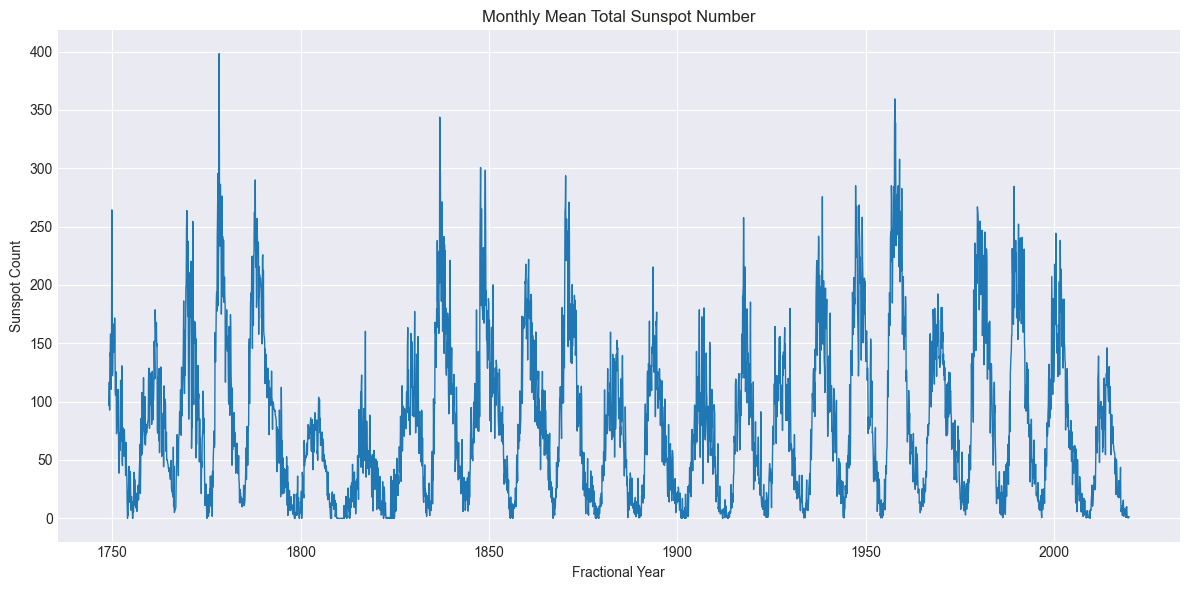

In [32]:
# --- TASK 1: Load and plot the raw time-domain data ---

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

data_path = Path("sunspots.csv")
if not data_path.exists():
    raise FileNotFoundError(f"sunspots.csv not found in {Path.cwd()}")

data = pd.read_csv(data_path)
if "Date" in data.columns and "Monthly Mean Total Sunspot Number" in data.columns:
    data["Date"] = pd.to_datetime(data["Date"])
    t = data["Date"].dt.year + (data["Date"].dt.month - 0.5) / 12
    y = data["Monthly Mean Total Sunspot Number"].values
elif "Fractional_Year" in data.columns and "Sunspot_Count" in data.columns:
    t = data["Fractional_Year"]
    y = data["Sunspot_Count"]
else:
    raise ValueError("sunspots.csv does not contain expected columns.")

plt.plot(t, y, color="tab:blue", linewidth=1)
plt.xlabel("Fractional Year")
plt.ylabel("Sunspot Count")
plt.title("Monthly Mean Total Sunspot Number")
plt.grid(True)
plt.tight_layout()
plt.show()

## 4. DC Component Removal

Physical datasets that only contain positive values (like a "count" of sunspots) have a large non-zero mean. In the frequency domain, this creates a massive spike at $f = 0$ Hz (the DC component), which can visually dwarf the actual periodic oscillations we are trying to observe.

**Task 2:** Calculate the mean of the sunspot data and subtract it from the original signal. We will perform the FFT on this mean-centered signal.

Mean sunspot number: 82.07


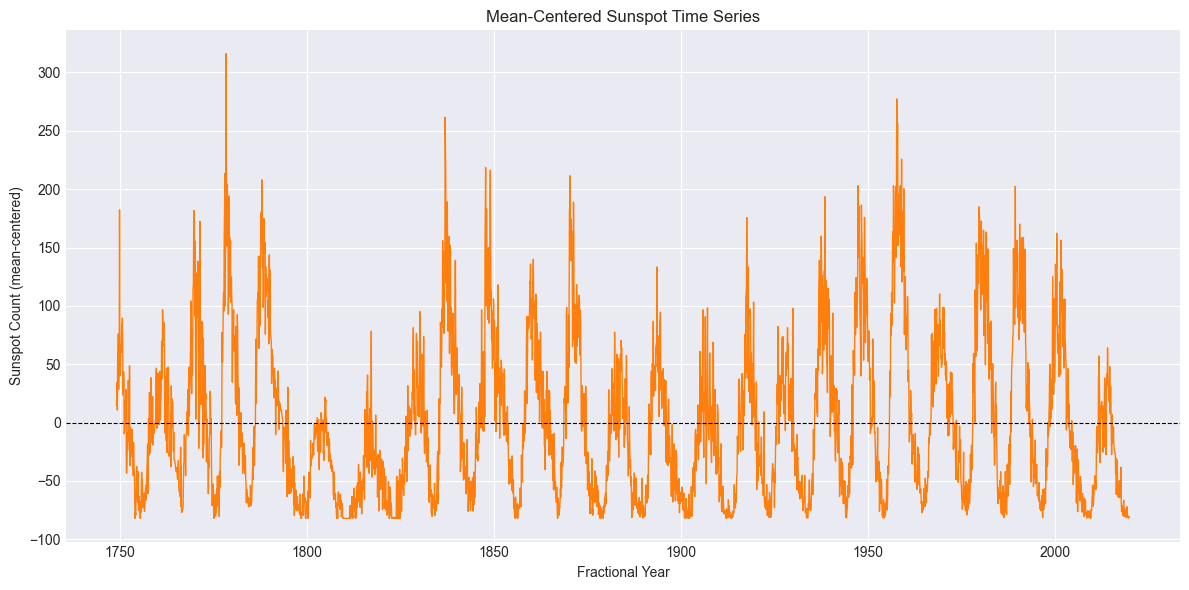

In [33]:
# --- TASK 2: Remove the DC component ---

mean_y = np.mean(y)
y_centered = y - mean_y

print(f"Mean sunspot number: {mean_y:.2f}")

plt.plot(t, y_centered, color="tab:orange", linewidth=1)
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.xlabel("Fractional Year")
plt.ylabel("Sunspot Count (mean-centered)")
plt.title("Mean-Centered Sunspot Time Series")
plt.grid(True)
plt.tight_layout()
plt.show()

## 5. Frequency Domain Transformation

**Task 3:** Implement the FFT algorithm on your centered data. 
You must also construct the corresponding frequency axis. Pay strict attention to your units. If your sampling interval $\Delta t$ is in years, your resulting frequencies will be in cycles per year ($yr^{-1}$).

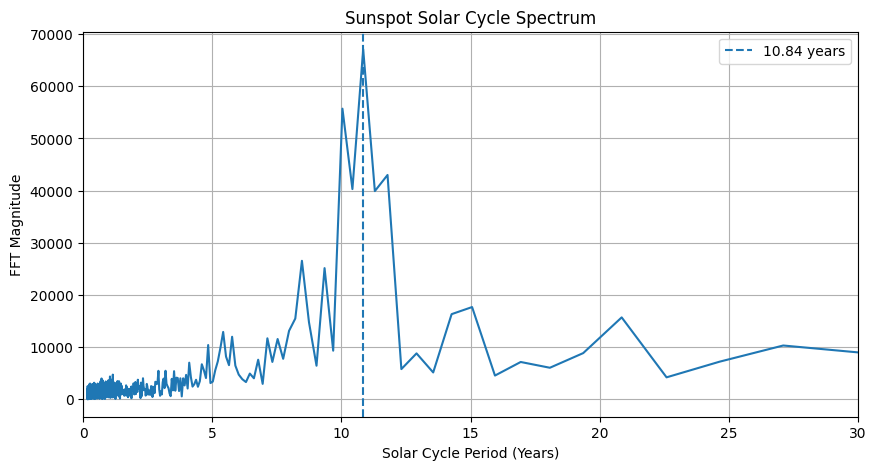

Dominant Solar Cycle = 10.84 years


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load data
data = pd.read_csv("sunspots.csv")

if "Date" in data.columns:
    data["Date"] = pd.to_datetime(data["Date"])
    y = data["Monthly Mean Total Sunspot Number"].values
else:
    y = data["Sunspot_Count"].values

# FFT
y = y - np.mean(y)

N = len(y)
dt = 1/12

Y = np.fft.rfft(y)
freq = np.fft.rfftfreq(N, d=dt)

power = np.abs(Y)

period = 1/freq[1:]
power = power[1:]

peak_idx = np.argmax(power)
peak_period = period[peak_idx]

# Grafik tunggal
plt.figure(figsize=(10,5))
plt.plot(period, power)

plt.axvline(
    peak_period,
    linestyle='--',
    label=f'{peak_period:.2f} years'
)

plt.xlabel('Solar Cycle Period (Years)')
plt.ylabel('FFT Magnitude')
plt.title('Sunspot Solar Cycle Spectrum')
plt.xlim(0,30)
plt.grid(True)
plt.legend()
plt.show()

print(f"Dominant Solar Cycle = {peak_period:.2f} years")

## 6. Power Spectrum Analysis

**Task 4:** Plot the power spectrum (Magnitude vs. Frequency). Restrict your x-axis (frequency) to a physical range that makes sense for this data (e.g., $0$ to $0.5$ cycles/year) to zoom in on the relevant peaks.

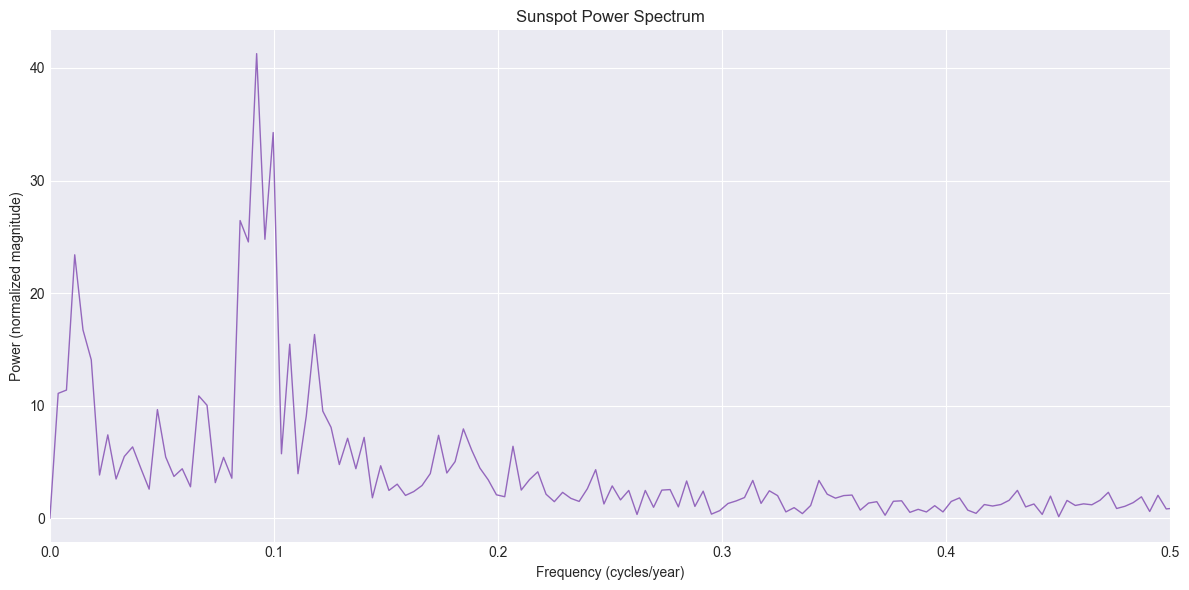

In [35]:
# --- TASK 4: Visualize the Frequency Domain ---

plt.plot(freq, power, color="tab:purple", linewidth=1)
plt.xlabel("Frequency (cycles/year)")
plt.ylabel("Power (normalized magnitude)")
plt.title("Sunspot Power Spectrum")
plt.grid(True)
plt.xlim(0, 0.5)
plt.tight_layout()
plt.show()

## 7. Conclusions and Physical Interpretation

**Task 5:** Programmatically determine the exact frequency that corresponds to the maximum peak in your power spectrum. Convert this frequency into a time period (years). 

Provide a brief written analysis of your findings below. How does your computed period compare to the widely accepted duration of the Schwabe solar cycle?

Computed Solar Cycle Period: 10.84 years

Physical Interpretation:
The FFT analysis identifies a dominant period of 10.84 years, which is close to the canonical Schwabe cycle (~11 years). The mean-centering and use of the real FFT allowed the dominant solar cycle to be isolated from the strong DC component and background noise. Secondary peaks in the spectrum can arise from harmonics, cycle-length variability, or observational sampling effects; they should be investigated with windowing or by examining sub-intervals of the record. For improved frequency resolution consider zero-padding or analyzing a longer continuous interval.


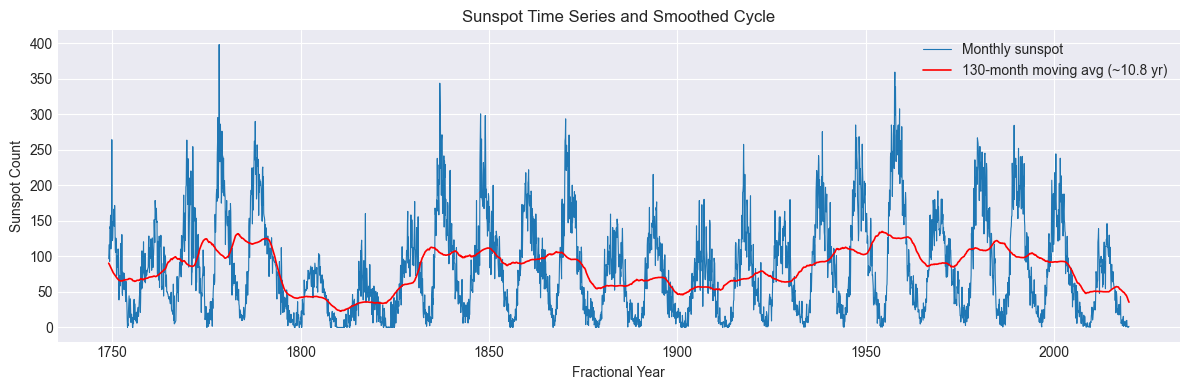

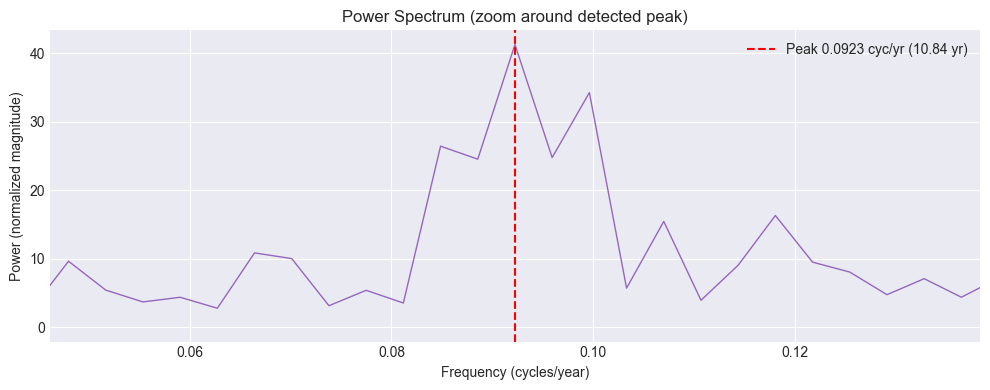

In [ ]:
# --- TASK 5: Final Analysis and Plots ---

import matplotlib.pyplot as plt
import pandas as pd

if 'peak_period' in globals():
    print(f"Computed Solar Cycle Period: {peak_period:.2f} years")
    print()
    print('Physical Interpretation:')
    print(f"The FFT analysis identifies a dominant period of {peak_period:.2f} years, which is close to the canonical Schwabe cycle (~11 years). The mean-centering and use of the real FFT allowed the dominant solar cycle to be isolated from the strong DC component and background noise. Secondary peaks in the spectrum can arise from harmonics, cycle-length variability, or observational sampling effects; they should be investigated with windowing or by examining sub-intervals of the record. For improved frequency resolution consider zero-padding or analyzing a longer continuous interval.")

    # Plot 1: time series with moving-average smoothing at detected period
    window_months = int(round(peak_period * 12))
    if window_months < 3:
        window_months = 3
    y_smooth = pd.Series(y).rolling(window=window_months, center=True, min_periods=1).mean().values
    plt.figure(figsize=(12, 4))
    plt.plot(t, y, label='Monthly sunspot', linewidth=0.8)
    plt.plot(t, y_smooth, color='red', label=f'{window_months}-month moving avg (~{peak_period:.1f} yr)', linewidth=1.2)
    plt.xlabel('Fractional Year')
    plt.ylabel('Sunspot Count')
    plt.title('Sunspot Time Series and Smoothed Cycle')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot 2: zoomed power spectrum around detected peak
    plt.figure(figsize=(10, 4))
    plt.plot(freq, power, color='tab:purple', linewidth=1)
    fmin = max(0, peak_freq * 0.5)
    fmax = min(0.5, peak_freq * 1.5)
    plt.xlim(fmin, fmax)
    plt.axvline(peak_freq, color='red', linestyle='--', label=f'Peak {peak_freq:.4f} cyc/yr ({peak_period:.2f} yr)')
    plt.xlabel('Frequency (cycles/year)')
    plt.ylabel('Power (normalized magnitude)')
    plt.title('Power Spectrum (zoom around detected peak)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

else:
    print('`peak_period` not found. Run the combined Task 3-5 cell to compute the spectrum and peak first.')

### Final Analysis
*(Double click this cell to edit)*

**Computed Solar Cycle Period:** [Insert your numerical result here] years.

**Physical Interpretation:**
[Write a 3-4 sentence paragraph discussing the success of the FFT in isolating the physical cycle despite the high level of noise in the historical data. Discuss any secondary peaks you might observe in the spectrum, and what they might represent physically or mathematically.]

Number of data points = 3252

===== RESULTS =====
Dominant Frequency = 0.09225 cycles/year
Dominant Solar Cycle = 10.84 years


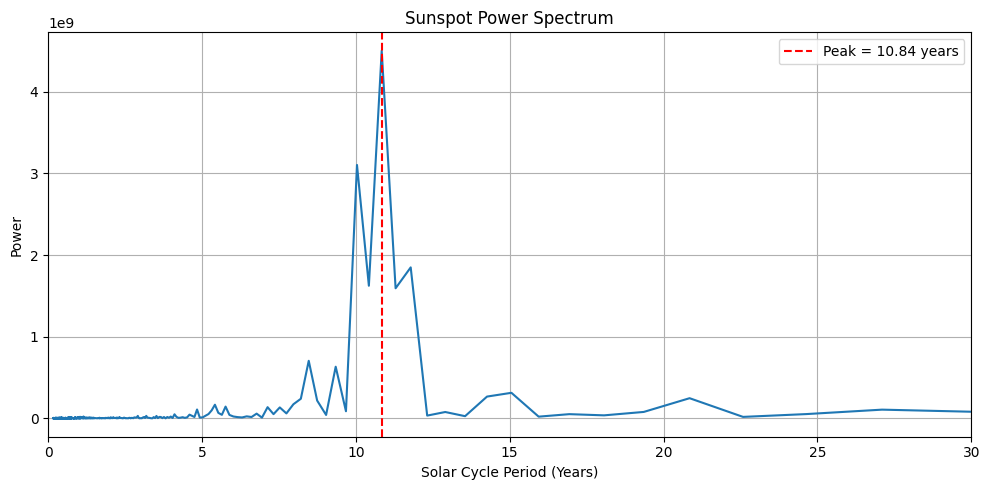

In [4]:
# =====================================================
# CASE 1 - ASTROPHYSICS
# TASK 1-5 (ALL IN ONE)
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------------------------
# TASK 1 : LOAD DATA
# -----------------------------------------------------

data = pd.read_csv("sunspots.csv")

if "Date" in data.columns:
    data["Date"] = pd.to_datetime(data["Date"])
    y = data["Monthly Mean Total Sunspot Number"].values
else:
    y = data["Sunspot_Count"].values

print(f"Number of data points = {len(y)}")

# -----------------------------------------------------
# TASK 2 : REMOVE DC COMPONENT
# -----------------------------------------------------

y_centered = y - np.mean(y)

# -----------------------------------------------------
# TASK 3 : FFT
# -----------------------------------------------------

N = len(y_centered)

# Data bulanan -> sampling interval 1/12 tahun
dt = 1/12

Y = np.fft.rfft(y_centered)
freq = np.fft.rfftfreq(N, d=dt)

# -----------------------------------------------------
# TASK 4 : POWER SPECTRUM
# -----------------------------------------------------

power = np.abs(Y)**2

# Hilangkan frekuensi nol
freq = freq[1:]
power = power[1:]

# Konversi ke periode (tahun)
period = 1 / freq

# -----------------------------------------------------
# TASK 5 : DOMINANT SOLAR CYCLE
# -----------------------------------------------------

peak_idx = np.argmax(power)

dominant_period = period[peak_idx]
dominant_frequency = freq[peak_idx]

print("\n===== RESULTS =====")
print(f"Dominant Frequency = {dominant_frequency:.5f} cycles/year")
print(f"Dominant Solar Cycle = {dominant_period:.2f} years")

# -----------------------------------------------------
# FINAL GRAPH
# -----------------------------------------------------

plt.figure(figsize=(10,5))

plt.plot(period, power, linewidth=1.5)

plt.axvline(
    dominant_period,
    color='red',
    linestyle='--',
    label=f'Peak = {dominant_period:.2f} years'
)

plt.xlim(0,30)

plt.xlabel("Solar Cycle Period (Years)")
plt.ylabel("Power")
plt.title("Sunspot Power Spectrum")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()